In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv('Real estate.csv')

In [3]:
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
data.drop(columns=['No', 'X1 transaction date'], inplace=True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X2 house age                            414 non-null    float64
 1   X3 distance to the nearest MRT station  414 non-null    float64
 2   X4 number of convenience stores         414 non-null    int64  
 3   X5 latitude                             414 non-null    float64
 4   X6 longitude                            414 non-null    float64
 5   Y house price of unit area              414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.columns=['age', 'MRT_dist', 'stores', 'lat', 'long', 'price']

In [8]:
data.describe()

,age,MRT_dist,stores,lat,long,price
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


<Axes: >

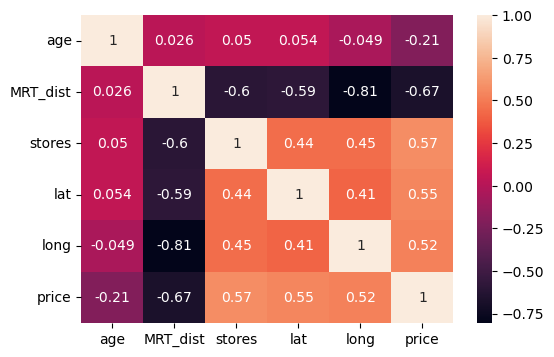

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True)

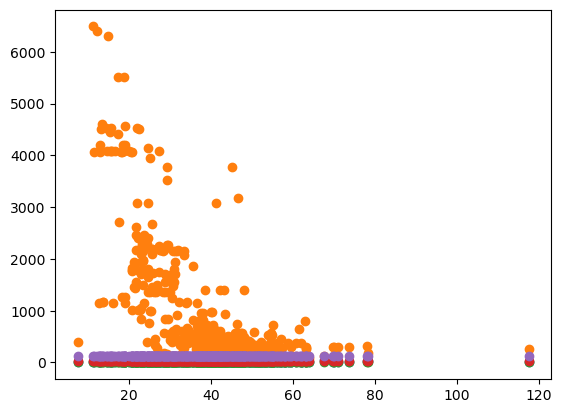

In [10]:
plt.scatter(x=data.price, y=data.age)
plt.scatter(x=data.price, y=data.MRT_dist)
plt.scatter(x=data.price, y=data.stores)
plt.scatter(x=data.price, y=data.lat)
plt.scatter(x=data.price, y=data.long)

In [11]:
X = data.drop(columns=['price'])
y= data[['price']]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
poly = PolynomialFeatures(3)
Xpoly_train = poly.fit_transform(X_train_scaled)
Xpoly_test = poly.fit_transform(X_test_scaled)

In [25]:
model= LinearRegression()
model.fit(Xpoly_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(Xpoly_test)

In [27]:
np.sqrt(mean_squared_error(y_pred, y_test))

np.float64(6.407549177804302)

In [28]:
r2_score(y_test, y_pred)

0.7552649678658471